In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM,
    Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow {tf.__version__} ✓")

TensorFlow 2.10.0 ✓


In [2]:
train = pd.read_csv("../data/train.csv")
val   = pd.read_csv("../data/val.csv")
test  = pd.read_csv("../data/test.csv")

print(f"Train : {len(train):,}")
print(f"Val   : {len(val):,}")
print(f"Test  : {len(test):,}")
train.head(3)

Train : 51,525
Val   : 7,361
Test  : 14,722


,text,label,clean_text,word_count,char_count
0,@SaudiMCI كيف استطيع الحصول على مستحقاتي من نظ...,neutral,كيف استطيع الحصول علي مستحقاتي من نظام السعوده...,23,119
1,@sakani_housing اسكان ابوعريش وش صار على الفلل...,neutral,اسكان ابوعريش وش صار علي الفلل وكيف اقدر احجز فيه,10,49
2,@MCgovSA مساء الخير فيه بقاله داخل محطه يرفض ا...,neutral,مساء الخير فيه بقاله داخل محطه يرفض الدفع بالش...,18,101


In [3]:
le = LabelEncoder()
le.fit(["negative", "neutral", "positive"])

y_train = le.transform(train["label"])
y_val   = le.transform(val["label"])
y_test  = le.transform(test["label"])

print("Classes:", le.classes_)
print("Encoding: negative=0, neutral=1, positive=2")

Classes: ['negative' 'neutral' 'positive']
Encoding: negative=0, neutral=1, positive=2


In [4]:
# ASAD is imbalanced: neutral ~69%, positive/negative ~15% each
# class_weight tells the model to penalize mistakes on minority classes more
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight = dict(enumerate(weights))

print("Class weights:")
for idx, label in enumerate(le.classes_):
    print(f"  {label:<10} → {class_weight[idx]:.4f}")

Class weights:
  negative   → 2.1084
  neutral    → 0.4856
  positive   → 2.1434


In [5]:
VOCAB_SIZE = 30_000   # larger vocab to cover ASAD's 73K tweets
MAX_LEN    = 50       # 95%+ of Arabic tweets fit within 50 tokens
OOV_TOKEN  = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train["clean_text"])

def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train = encode(train["clean_text"])
X_val   = encode(val["clean_text"])
X_test  = encode(test["clean_text"])

print(f"Vocab size : {len(tokenizer.word_index):,}")
print(f"X_train    : {X_train.shape}")
print(f"X_val      : {X_val.shape}")
print(f"X_test     : {X_test.shape}")

Vocab size : 89,439
X_train    : (51525, 50)
X_val      : (7361, 50)
X_test     : (14722, 50)


In [6]:
EMBED_DIM   = 128
LSTM_UNITS  = 64
NUM_CLASSES = len(le.classes_)   # 3

inp = Input(shape=(MAX_LEN,))
x   = Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN)(inp)
x   = SpatialDropout1D(0.3)(x)
x   = Bidirectional(LSTM(LSTM_UNITS, return_sequences=True))(x)
x   = Bidirectional(LSTM(LSTM_UNITS // 2))(x)
x   = Dense(64, activation="relu")(x)
x   = Dropout(0.4)(x)
out = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inp, out)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 50)]              0         
                                                                 
 embedding (Embedding)       (None, 50, 128)           3840000   
                                                                 
 spatial_dropout1d (SpatialD  (None, 50, 128)          0         
 ropout1D)                                                       
                                                                 
 bidirectional (Bidirectiona  (None, 50, 128)          98816     
 l)                                                              
                                                                 
 bidirectional_1 (Bidirectio  (None, 64)               41216     
 nal)                                                            
                                                             

In [7]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    class_weight=class_weight,   # handles neutral dominance
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
806/806 [==============================] - 140s 140ms/step - loss: 0.8293 - accuracy: 0.6028 - val_loss: 0.6731 - val_accuracy: 0.6988 - lr: 0.0010
Epoch 2/30
806/806 [==============================] - 106s 132ms/step - loss: 0.5576 - accuracy: 0.7493 - val_loss: 0.7021 - val_accuracy: 0.6991 - lr: 0.0010
Epoch 3/30
806/806 [==============================] - ETA: 0s - loss: 0.3872 - accuracy: 0.8195
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
806/806 [==============================] - 107s 133ms/step - loss: 0.3872 - accuracy: 0.8195 - val_loss: 0.7546 - val_accuracy: 0.7056 - lr: 0.0010
Epoch 4/30
806/806 [==============================] - 108s 134ms/step - loss: 0.2270 - accuracy: 0.8897 - val_loss: 0.8825 - val_accuracy: 0.6998 - lr: 5.0000e-04
Epoch 5/30
806/806 [==============================] - ETA: 0s - loss: 0.1698 - accuracy: 0.9180Restoring model weights from the end of the best epoch: 1.

Epoch 5: ReduceLROnPlateau reducing learning

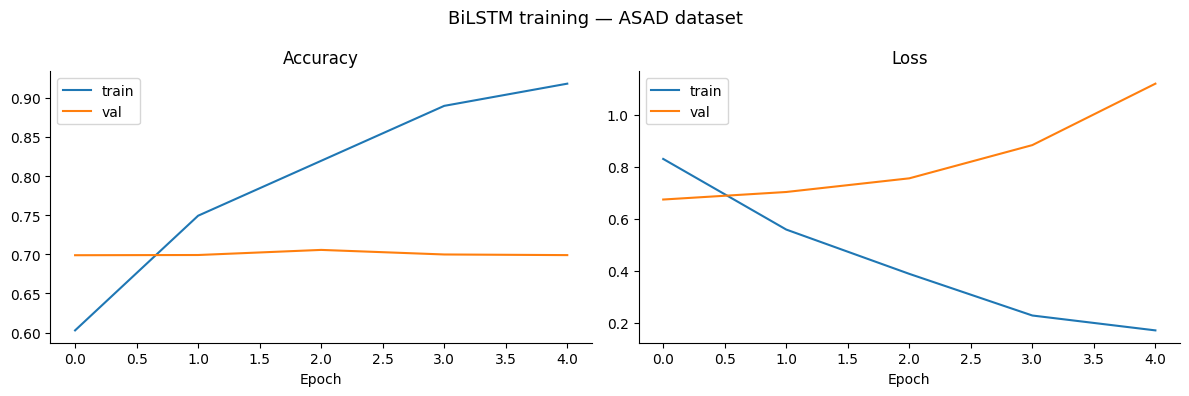

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"],     label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(history.history["loss"],     label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle("BiLSTM training — ASAD dataset", fontsize=13)
plt.tight_layout()
plt.savefig("../results/training_curves.png", dpi=150)
plt.show()

In [9]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss     : {loss:.4f}")
print(f"Test accuracy : {acc:.4f}\n")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print("── BiLSTM Classification Report ──\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Test loss     : 0.6763
Test accuracy : 0.6944

── BiLSTM Classification Report ──

              precision    recall  f1-score   support

    negative       0.42      0.74      0.54      2327
     neutral       0.89      0.71      0.79     10105
    positive       0.53      0.60      0.56      2290

    accuracy                           0.69     14722
   macro avg       0.61      0.68      0.63     14722
weighted avg       0.76      0.69      0.71     14722



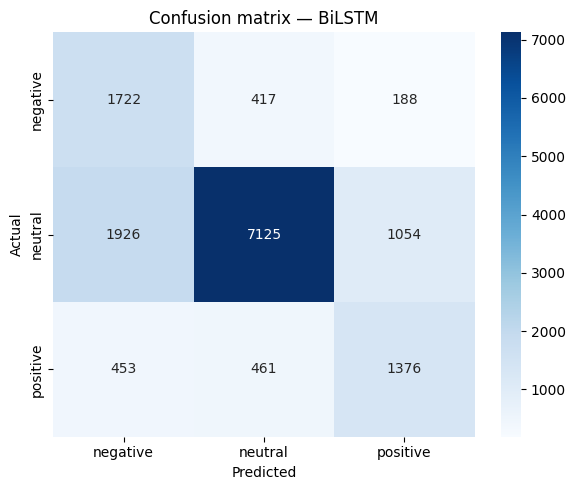

In [10]:
LABEL_COLORS = {"positive": "#1D9E75", "negative": "#D85A30", "neutral": "#888780"}

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix — BiLSTM")
plt.tight_layout()
plt.savefig("../results/confusion_matrix.png", dpi=150)
plt.show()

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=30_000, ngram_range=(1, 2))
X_tr_tfidf   = tfidf.fit_transform(train["clean_text"])
X_test_tfidf = tfidf.transform(test["clean_text"])

lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_tr_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)
print("── TF-IDF + Logistic Regression ──\n")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

── TF-IDF + Logistic Regression ──

              precision    recall  f1-score   support

    negative       0.46      0.66      0.55      2327
     neutral       0.89      0.72      0.79     10105
    positive       0.48      0.66      0.56      2290

    accuracy                           0.70     14722
   macro avg       0.61      0.68      0.63     14722
weighted avg       0.76      0.70      0.72     14722



In [12]:
from sklearn.metrics import f1_score, accuracy_score

results = pd.DataFrame({
    "Model": ["TF-IDF + LR (baseline)", "BiLSTM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred)
    ],
    "F1 macro": [
        f1_score(y_test, y_pred_lr, average="macro"),
        f1_score(y_test, y_pred,    average="macro")
    ],
    "F1 weighted": [
        f1_score(y_test, y_pred_lr, average="weighted"),
        f1_score(y_test, y_pred,    average="weighted")
    ],
}).round(4)

results.to_csv("../results/model_comparison.csv", index=False)
print(results.to_string(index=False))

                 Model  Accuracy  F1 macro  F1 weighted
TF-IDF + LR (baseline)    0.7025    0.6326       0.7180
                BiLSTM    0.6944    0.6278       0.7121


In [13]:
model.save("../models/bilstm_arabic_sentiment.keras")

with open("../models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("../models/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Saved:")
print("../models/bilstm_arabic_sentiment.keras")
print("../models/tokenizer.pkl")
print("../models/label_encoder.pkl")

Saved:
../models/bilstm_arabic_sentiment.keras
../models/tokenizer.pkl
../models/label_encoder.pkl
